In [9]:
import numpy as np
import networkx as nx
import pprint

from spidercss.cat_at_origin import *
from spidercss.utils import load_qecc
from spidercss.hook_errors import characterize_stabilizer_splits, explain_safe_splits
from spidercss.utils import get_conj_M


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
code = "4_2_2"
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)
t = d // 2
basis = "X" if code in ("15_1_3", "49_1_5", "95_1_7") else "Z"
if basis == "X":
    H_x, H_z = H_z, H_x
    L_x, L_z = L_z, L_x
cost, row_M = row_optimize_matrix(H_x, t=t, max_basis_tries=1_000)  # |0>

for r in get_conj_M(row_M):
    print(f"\t[{r[0]}", end="")
    for e in r[1:]:
        print(f", {e}", end="")
    print("],")
print(cost)

	[1, 1, 0, 0],
	[1, 0, 1, 0],
	[1, 0, 0, 1],
5


In [11]:
explain_safe_splits(characterize_stabilizer_splits(get_conj_M(row_M)))

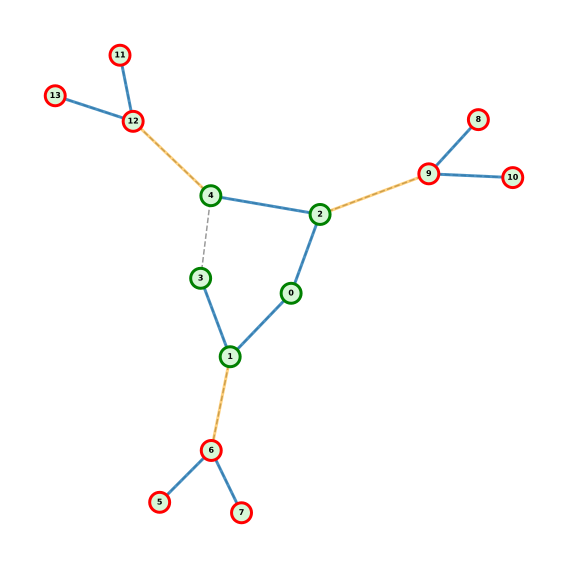

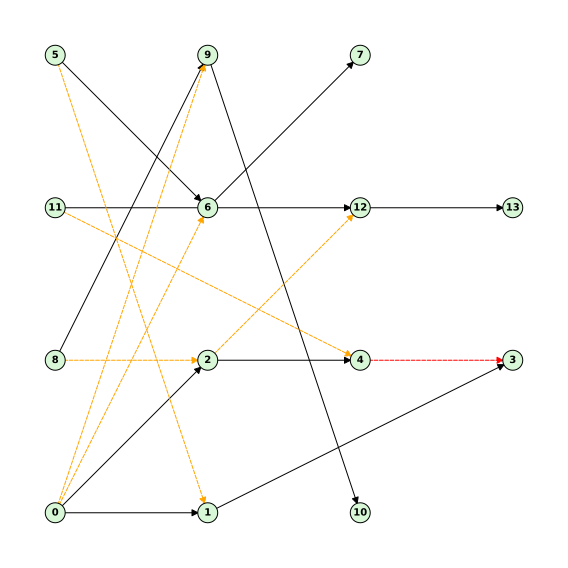

In [12]:
circ = cat_at_origin(row_M, d, basis=basis, draw_solutions=True, analyze_hook_errors=True)
# circ2 = cat_at_origin(row_M, d, basis=basis, draw_solutions=False, analyze_hook_errors=False)

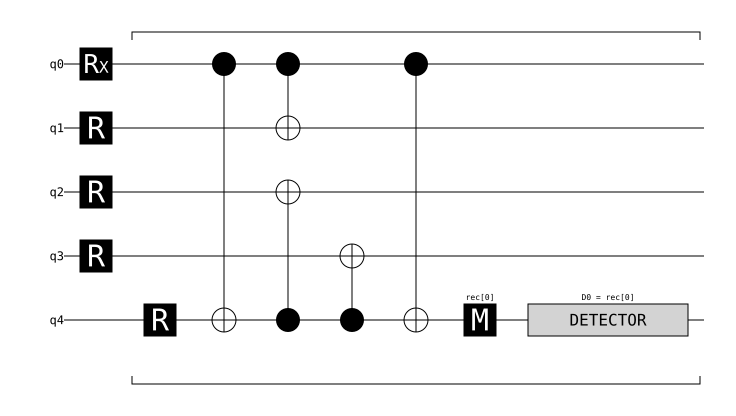

In [6]:
circ.diagram('timeline-svg')

In [7]:
circuit = circ.copy()
circuit.append("M" + basis, range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print(meas_samples @ L_z.T % 2)

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]]


In [8]:
from spidercss.utils import _layer_cnot_circuit

raw_cnots = [l for (name, l, _) in circ.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num Flags:", circ.num_qubits - H_z.shape[1])
print("Num qubits:", circ.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

Num CX: 5
Num Flags: 1
Num qubits: 5
Depth: 4
